<a href="https://colab.research.google.com/github/Idybaz/StoryAnalyser/blob/main/ProjectDraft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install & Import Required Libraries**

**Installation of Libraries**

In [3]:
!pip install contractions textstat spacy nltk pandas numpy scikit-learn lexical-diversity pronouncing

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.8/117.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 8.4 MB/s eta 0:00:00
  Created wheel for pronouncing: filename=pronouncing-0.2.0-py2.py3-none-any.whl size=6233 sha256=9855b41d70ee9a5cb26841e6ea1c7fe2277b9e9d8dc3af315871020cb0e8e691
  Stored in directory: /root/.cache/pip/wheels/8b/81/fd/7edbf09827c7a7e2666e870b4c5c6b46c7ebd5defa399698bd
Successfully built pronouncing


**Import Necessary Libraries**

In [4]:
import re
import numpy as np
import pandas as pd
import contractions
import textstat
import nltk
import spacy
import pronouncing
import gensim
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from spacy.matcher import Matcher
from spacy.symbols import aux, advmod, nsubj, VERB, PRON
from sklearn.preprocessing import MinMaxScaler
from textstat import flesch_reading_ease, flesch_kincaid_grade, dale_chall_readability_score
from collections import Counter
from lexical_diversity import lex_div as ld
from gensim import corpora
from gensim.models import LdaModel
from textblob import TextBlob


**Download NLTK Resources**

In [5]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

**Load SpaCy English model**

In [6]:
nlp = spacy.load("en_core_web_sm")

# **Load the Dataset**

In [7]:
# Load the dataset
df = pd.read_excel("/content/drive/MyDrive/final_sample_500_books.xlsx")

# Display the first few rows to confirm the dataset was loaded correctly
df.head(184)

,Book Title,Author(s),ISBN-1,Total Pages,Word Count,Character Count,First 5 Pages,Last 3 Pages,Story Text,Content,Master_Publisher,Master_Publication date,Master_Primary author,Master_Primary illustrator,Master_Title,Master_Raw text,Master_Publisher Keywords1,Master_Publisher Keywords2,Master_Publisher Keywords3,Combined_Category
0,Little Mermaid,"Bowles, A. & Nowowiejska",9781788813693,36,908,5036,Пр FAIRYTALE CLASSICS Little Mermaid Anna Bowl...,\n \n FROM THE SEA! YOU SAVED ME! A little mer...,To Amira - AB For my sweet Helena and her frie...,At the bottom of the sea lay the kingdom of th...,Little Tiger Pr,2020-06-02,"Bowles, Anna","Nowowiejska, Kasia",Little mermaid,"At the bottom of the sea, lay the kingdom of t...",Fairy tales,Mythical creatures,Romance,"Fairy tales, Mythical creatures, Romance"
1,That Rabbit Belongs to Emily Brown,"Cowell, C. & Layton, N.",9781444923414,36,1004,5531,CRESSIDA COWELL AND NEAL LAYTON THAT RABBIT be...,It was the Postman with a letter for Emily Bro...,"Once upon a time, there was a little girl call...","Once upon a time, there was a little girl call...",Hodder,2015-05-03,"Cowell, Cressida","Layton, Neal",That rabbit belongs to Emily Brown,once upon a time there was a little girl calle...,Award winners,Royalty,Toys,"Award winners, Royalty, Toys"
2,WE PLANTED A PUMPKIN,RAMSDEN R.,9781912650866,36,241,1258,ROB RAMSDEN We planted a PUMPKIN\n 22. Me bjen...,On the night of Halloween. L\n \n BOB RAMSDEN'...,"\n This is us. ·L\n \n ☆ We planted a seed, to...","? We planted a seed, to grow a pumpkin for Hal...",UNKNOWN,2023-05-05,"Ramsden, Rob","Ramsden, Rob",We planted a pumpkin,This is us we planted a seed to grow a pumpkin...,Gardens and gardening,Multicultural society,Plants,"Gardens and gardening, Multicultural society, ..."
3,OLD MACDONALD HAD A PHONE,WILLIS J & ROSS T.,9781783449538,34,595,3193,"11 11, 5 OLD MACDONALD had a \ s PHONE A great...","\n \n Old Macdonald loves his phone, he thinks...",For Danni Corgan - J.W. For a complete list of...,"Old Macdonald had a phone,\nAnd it was very sm...",Andersen Pr,2022-03-02,"Willis, Jeanne","Ross, Tony",Old Macdonald had a phone,Old macdonald had a phone and it was very smar...,Animal stories,Stories in rhyme,Safety education,"Animal stories, Stories in rhyme, Safety educa..."
4,Show and Tell,"Biddulph, R.",9780008318031,36,640,3503,"SHATI ""A delightful tale"" The Times Rob Biddul...","SCHOOL GARDEN Jule ""...it has magic inside it....",Meet Class 2L. These kids are excited.\n Вь וי...,Meet Class 2L. These kids are excited.\nToday'...,HarperCollins,2020-06-02,"Biddulph, Rob","Biddulph, Rob",Show and tell,meet class l2l these kids are excited today is...,Multicultural society,Stories in rhyme,School stories,"Multicultural society, Stories in rhyme, Schoo..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,Astro Girl,"Wilson Max K.,",9781910959213,32,471,2568,Ken Wilson-Max ASTRO GIRL\n \n \n CEL To my fr...,"\n \n Astrid loves the stars and space. ""I wan...",Astrid had loved the stars. and space ever sin...,Astrid had loved the stars ever since she coul...,Otter-Barry Books Ltd,2019-06-06,"Wilson-Max, Ken","Wilson-Max, Ken",Astro girl,Astrid had loved the stars and space ever sinc...,Imagination,Space flight,Space,"Imagination, Space flight, Space"
180,STORY SOUP,LONGSTAFF A. & AYE N.,9781787415591,44,1071,5963,Discover the recipe for adventure.. • Soup чо ...,Chungle Bubble Flump Bing\n \n ་ 4 Ollie and S...,Ollie was mixing a story. He stirred the soup ...,Ollie was mixing a story. He stirred the soup ...,Templar Pub,2021-08-07,"Longstaff, Abie","Aye, Nila",Story soup,ollie was mixing a story he stirred the soup p...,Imagination,Adventure stories,NaN,"Imagination, Adventure stories, nan"
181,Gnome,"Blunt, F.",9781783449347,36,411,1920,Gnome M m The little fellow with gNome manners...,The End\n 00 00\n Winner of the This little fe...,This little fellow is a gnome. ६ M M es\n Say ...,This little fellow is

# **Multi-Level Cleaning for Different Analyses**

General Cleaning

In [8]:
def preclean_text(text):
    """General cleaning: Removes only strange characters while keeping punctuation and structure."""
    if pd.isna(text):
        return ""

    # Remove metadata (e.g., copyright info, ISBN, websites, illustrator credits)
    text = re.sub(r"(?i)(copyright|published by|isbn|www\.|illustrated by).*", "", text)

    # Remove all non-English characters
    text = re.sub(r"[^\x00-\x7F]", "", text)   # Removes non-ASCII characters only

    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


**Readability Cleaning**

In [9]:
def clean_for_readability(text):
    """Minimal cleaning: Preserve original structure for readability analysis."""
    if pd.isnull(text):
        return ""

    # Normalize punctuation & quotes
    text = text.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')

    # Fix spaces around punctuation
    text = re.sub(r"\s+([.,!?'])", r"\1", text)  # No extra space before punctuation
    text = re.sub(r"([.,!?'])\s+", r"\1 ", text)  # Ensure space after punctuation

    return text.strip()

**Lexical Diversity Cleaning**

In [10]:
def clean_for_lexical_diversity(text):
    """Prepares text for lexical diversity analysis: Expands contractions, lowercases text."""
    if pd.isnull(text):
        return ""

    # Expand contractions ("can't" → "cannot")
    text = contractions.fix(text)

    # Normalize punctuation
    text = text.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')

    # Lowercase for consistency
    text = text.lower()

    # Fix spacing around punctuation
    text = re.sub(r"\s+([.,!?'])", r"\1", text)
    text = re.sub(r"([.,!?'])\s+", r"\1 ", text)

    return text.strip()

**Engagement Cleaning**

In [11]:
def merge_rhyming_lines(text):
    """Merge lines into stanzas for better phrase/rhyhme analysis"""
    return re.sub(r'([^\n])\n([^\n])', r'\1 \2', text)  # Merge line breaks not at paragraph ends

def clean_for_engagement(text):
    """Enhanced cleaning preserving poetic structure"""
    text = merge_rhyming_lines(text)
    # Keep original capitalization (important for rhyme detection)
    text = re.sub(r"[^\w\s'.,?!-]", "", text)
    return re.sub(r"\s+", " ", text).strip()

**Sentiment Cleaning**

In [12]:
def clean_for_sentiment(text):
    """Prepares text for sentiment analysis: Expands contractions, removes punctuation."""
    if pd.isnull(text):
        return ""

    if pd.isnull(text):
        return ""

    # Expand contractions ("can't" → "cannot")
    text = contractions.fix(text)

    # Merge rhyming lines (preserve poetic structure)
    text = re.sub(r'([^\n])\n([^\n])', r'\1 \2', text)

    # Keep key punctuation (.,!?-) while removing unnecessary symbols
    text = re.sub(r"[^\w\s.,!?'-]", "", text)

    # Fix extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

 **Thematic Cleaning**

In [13]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tags to WordNet format for lemmatization."""
    tag = pos_tag([word])[0][1]
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag[0].upper(), wordnet.NOUN)

def clean_for_thematic_analysis(text):
    """Prepares text for thematic analysis: Lemmatizes words, removes stopwords & punctuation."""
    if pd.isnull(text):
        return ""

    # Expand contractions ("she's" → "she is")
    text = contractions.fix(text)

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Tokenize words
    words = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]

    return " ".join(lemmatized_words)

**Applying Cleaning to StoryBook**

In [14]:
df["PreClean_Text"] = df["Content"].astype(str).apply(preclean_text)

# Apply Readability Cleaning (Minimal processing)
df["Cleaned_Content_Readability"] = df["PreClean_Text"].apply(clean_for_readability)

# Apply Lexical Diversity Cleaning (Lowercase + Expand Contractions)
df["Cleaned_Content_Lexical"] = df["PreClean_Text"].apply(clean_for_lexical_diversity)

# Apply Thematic Cleaning
df["Cleaned_Content_Engagement"] = df["PreClean_Text"].apply(clean_for_engagement)

# Apply Sentiment Cleaning (Lowercase + Remove Punctuation)
df["Cleaned_Content_Sentiment"] = df["PreClean_Text"].apply(clean_for_sentiment)

# Apply Thematic Cleaning (Lemmatization + Remove Stopwords)
df["Cleaned_Content_Thematic"] = df["PreClean_Text"].apply(clean_for_thematic_analysis)

# Display a sample
df[["Book Title", "Content", "PreClean_Text", "Cleaned_Content_Readability", "Cleaned_Content_Engagement", "Cleaned_Content_Lexical",
    "Cleaned_Content_Sentiment", "Cleaned_Content_Thematic"]].head(183)

,Book Title,Content,PreClean_Text,Cleaned_Content_Readability,Cleaned_Content_Engagement,Cleaned_Content_Lexical,Cleaned_Content_Sentiment,Cleaned_Content_Thematic
0,Little Mermaid,At the bottom of the sea lay the kingdom of th...,At the bottom of the sea lay the kingdom of th...,At the bottom of the sea lay the kingdom of th...,At the bottom of the sea lay the kingdom of th...,at the bottom of the sea lay the kingdom of th...,At the bottom of the sea lay the kingdom of th...,bottom sea lay kingdom merpeople crab scuttle ...
1,That Rabbit Belongs to Emily Brown,"Once upon a time, there was a little girl call...","Once upon a time, there was a little girl call...","Once upon a time, there was a little girl call...","Once upon a time, there was a little girl call...","once upon a time, there was a little girl call...","Once upon a time, there was a little girl call...",upon time little girl call emily brown old gre...
2,WE PLANTED A PUMPKIN,"? We planted a seed, to grow a pumpkin for Hal...","? We planted a seed, to grow a pumpkin for Hal...","? We planted a seed, to grow a pumpkin for Hal...","? We planted a seed, to grow a pumpkin for Hal...","? we planted a seed, to grow a pumpkin for hal...","? We planted a seed, to grow a pumpkin for Hal...",plant seed grow pumpkin halloween beneath eart...
3,OLD MACDONALD HAD A PHONE,"Old Macdonald had a phone,\nAnd it was very sm...","Old Macdonald had a phone, And it was very sma...","Old Macdonald had a phone, And it was very sma...","Old Macdonald had a phone, And it was very sma...","old macdonald had a phone, and it was very sma...","Old Macdonald had a phone, And it was very sma...",old macdonald phone smart help organise farm f...
4,Show and Tell,Meet Class 2L. These kids are excited.\nToday'...,Meet Class 2L. These kids are excited. Today's...,Meet Class 2L. These kids are excited. Today's...,Meet Class 2L. These kids are excited. Today's...,meet class 2l. these kids are excited. today's...,Meet Class 2L. These kids are excited. Today's...,meet class 2l kid excite today show tell day c...
...,...,...,...,...,...,...,...,...
178,Naughty Kitty,"Lily wanted a doggy, but her mum said dogs wer...","Lily wanted a doggy, but her mum said dogs wer...","Lily wanted a doggy, but her mum said dogs wer...","Lily wanted a doggy, but her mum said dogs wer...","lily wanted a doggy, but her mum said dogs wer...","Lily wanted a doggy, but her mum said dogs wer...",lily want doggy mum say dog messy smelly far m...
179,Astro Girl,Astrid had loved the stars ever since she coul...,Astrid had loved the stars ever since she coul...,Astrid had loved the stars ever since she coul...,Astrid had loved the stars ever since she coul...,astrid had loved the stars ever since she coul...,Astrid had loved the stars ever since she coul...,astrid love star ever since could remember wan...
180,STORY SOUP,Ollie was mixing a story. He stirred the soup ...,Ollie was mixing a story. He stirred the soup ...,Ollie was mixing a story. He stirred the soup ...,Ollie was mixing a story. He stirred the soup ...,ollie was mixing a story. he stirred the soup ...,Ollie was mixing a story. He stirred the soup ...,ollie mix story stir soup pot add toy ore e bu...
181,Gnome,This little fellow is a gnome. ६ M M es\n Say ...,This little fellow is a gnome. M M es Say hell...,This little fellow is a gnome. M M es Say hell...,This little fellow is a gnome. M M es Say hell...,this little fellow is a gnome. m m es say hell...,This little fellow is a gnome. M M es Say hell...,little fellow gnome e say hello reader mr gnom...


**Overview of Text Cleaning of Text**

In [15]:
# Compute word counts for each version
df["Raw_Word_Count"] = df["Content"].apply(lambda x: len(str(x).split()))
df["Word_Count_Readability"] = df["Cleaned_Content_Readability"].apply(lambda x: len(str(x).split()))
df["Word_Count_Engagement"] = df["Cleaned_Content_Engagement"].apply(lambda x: len(str(x).split()))
df["Word_Count_Lexical"] = df["Cleaned_Content_Lexical"].apply(lambda x: len(str(x).split()))
df["Word_Count_Sentiment"] = df["Cleaned_Content_Sentiment"].apply(lambda x: len(str(x).split()))
df["Word_Count_Thematic"] = df["Cleaned_Content_Thematic"].apply(lambda x: len(str(x).split()))

# Display word count differences
df[["Book Title", "Raw_Word_Count", "Word_Count_Readability", "Word_Count_Engagement",
    "Word_Count_Lexical", "Word_Count_Sentiment", "Word_Count_Thematic"]].head()


,Book Title,Raw_Word_Count,Word_Count_Readability,Word_Count_Engagement,Word_Count_Lexical,Word_Count_Sentiment,Word_Count_Thematic
0,Little Mermaid,438,438,438,441,441,241
1,That Rabbit Belongs to Emily Brown,500,499,500,512,513,268
2,WE PLANTED A PUMPKIN,214,207,213,210,216,111
3,OLD MACDONALD HAD A PHONE,400,400,400,405,405,214
4,Show and Tell,348,348,348,358,358,217


In [16]:
# Function to compute unique vocabulary size
def compute_vocab_size(text):
    words = str(text).split()  # Tokenize by whitespace
    unique_words = set(words)  # Get unique words
    return len(unique_words)

# Apply vocabulary size calculations
df["Raw_Vocab_Size"] = df["Content"].apply(compute_vocab_size)
df["Vocab_Size_Readability"] = df["Cleaned_Content_Readability"].apply(compute_vocab_size)
df["Vocab_Size_Engagement"] = df["Cleaned_Content_Engagement"].apply(compute_vocab_size)
df["Vocab_Size_Lexical"] = df["Cleaned_Content_Lexical"].apply(compute_vocab_size)
df["Vocab_Size_Sentiment"] = df["Cleaned_Content_Sentiment"].apply(compute_vocab_size)
df["Vocab_Size_Thematic"] = df["Cleaned_Content_Thematic"].apply(compute_vocab_size)

# Display first few rows
df[["Book Title", "Raw_Vocab_Size", "Vocab_Size_Readability", "Vocab_Size_Engagement",
    "Vocab_Size_Lexical", "Vocab_Size_Sentiment", "Vocab_Size_Thematic"]].head()


,Book Title,Raw_Vocab_Size,Vocab_Size_Readability,Vocab_Size_Engagement,Vocab_Size_Lexical,Vocab_Size_Sentiment,Vocab_Size_Thematic
0,Little Mermaid,270,270,267,259,267,164
1,That Rabbit Belongs to Emily Brown,285,284,283,263,280,158
2,WE PLANTED A PUMPKIN,134,134,129,126,130,70
3,OLD MACDONALD HAD A PHONE,239,239,239,217,238,141
4,Show and Tell,267,267,262,254,259,176


In [17]:
# Compute percentage change in vocabulary size
df["Reduction_Vocab_Readability (%)"] = 100 * (df["Raw_Vocab_Size"] - df["Vocab_Size_Readability"]) / df["Raw_Vocab_Size"]
df["Reduction_Vocab_Engagement (%)"] = 100 * (df["Raw_Vocab_Size"] - df["Vocab_Size_Engagement"]) / df["Raw_Vocab_Size"]
df["Reduction_Vocab_Lexical (%)"] = 100 * (df["Raw_Vocab_Size"] - df["Vocab_Size_Lexical"]) / df["Raw_Vocab_Size"]
df["Reduction_Vocab_Sentiment (%)"] = 100 * (df["Raw_Vocab_Size"] - df["Vocab_Size_Sentiment"]) / df["Raw_Vocab_Size"]
df["Reduction_Vocab_Thematic (%)"] = 100 * (df["Raw_Vocab_Size"] - df["Vocab_Size_Thematic"]) / df["Raw_Vocab_Size"]

# Display first few rows
df[["Book Title", "Raw_Vocab_Size", "Vocab_Size_Thematic", "Reduction_Vocab_Thematic (%)"]].head()


,Book Title,Raw_Vocab_Size,Vocab_Size_Thematic,Reduction_Vocab_Thematic (%)
0,Little Mermaid,270,164,39.259259
1,That Rabbit Belongs to Emily Brown,285,158,44.561404
2,WE PLANTED A PUMPKIN,134,70,47.761194
3,OLD MACDONALD HAD A PHONE,239,141,41.004184
4,Show and Tell,267,176,34.082397


# **Text Analysis With NLP**

**Readability Analysis**

In [18]:
def compute_readability(text):
    """Computes FRE, Sentence Length, and Clause Density"""
    if not isinstance(text, str) or text.strip() == "":
        return pd.Series([np.nan, np.nan, np.nan])

    fre = textstat.flesch_reading_ease(text)  # Higher = Easier
    sentence_length = np.mean([len(sent.split()) for sent in nltk.sent_tokenize(text)])  # Lower = Easier
    clause_density = textstat.smog_index(text) / 10  # Lower = Easier

    return pd.Series([fre, sentence_length, clause_density])

df[["Flesch_Reading_Ease", "Sentence_Length", "Clause_Density"]] = df["Cleaned_Content_Readability"].apply(compute_readability)
print(df[["Book Title", "Flesch_Reading_Ease", "Sentence_Length", "Clause_Density"]].head())

                           Book Title  Flesch_Reading_Ease  Sentence_Length  \
0                      Little Mermaid                85.49         9.521739   
1  That Rabbit Belongs to Emily Brown                75.40        11.604651   
2                WE PLANTED A PUMPKIN                91.27         6.272727   
3           OLD MACDONALD HAD A PHONE                92.22        14.814815   
4                       Show and Tell                80.58         7.733333   

   Clause_Density  
0            0.72  
1            0.91  
2            0.54  
3            0.77  
4            0.79  


**Engagement Analysis**

In [19]:
def phrase_repetition_score(text, min_phrase_length=2, max_phrase_length=4):
    """Flexible phrase length detection with exact match merging"""
    words = [w.lower() for w in word_tokenize(text) if w not in ['.', '?', '!']]

    phrases = []
    for n in range(min_phrase_length, max_phrase_length+1):
        phrases.extend([' '.join(gram) for gram in ngrams(words, n)])

    # Count multi-word exact matches (case-insensitive)
    phrase_counts = Counter(phrases)
    repeated_phrases = sum(count for phrase, count in phrase_counts.items()
                          if count > 1 and len(phrase.split()) >= 2)

    return repeated_phrases / max(1, len(phrases))


CUSTOM_RHYMES = {
    'plumpkin': ['pumpkin', 'bumpkin'],
    'yolo': ['jello', 'fellow'],
    'whatsapping': ['clapping', 'mapping']
}

def get_rhyme_part(word):
    """Hybrid approach using CMUdict + custom mappings"""
    word = word.lower()
    if word in CUSTOM_RHYMES:
        return CUSTOM_RHYMES[word][0]  # Use first custom rhyme

    phones = pronouncing.phones_for_word(word)
    return pronouncing.rhyming_part(phones[0]) if phones else word[-3:]

def rhyme_score(text, window=4):
    """Detects slant rhymes and custom words"""
    words = [w for w in word_tokenize(text) if w.isalpha()]
    rhymes = 0

    for i in range(len(words)):
        for j in range(i+1, min(i+window+1, len(words))):
            rhyme1 = get_rhyme_part(words[i])
            rhyme2 = get_rhyme_part(words[j])

            # Match last 3 letters for slant rhymes
            if rhyme1[-3:] == rhyme2[-3:]:
                rhymes += 1

    return rhymes / max(1, len(words))


def is_question(sent):
    """Detects questions using syntax tree analysis"""
    # Check for explicit question mark
    if sent.text.endswith('?'):
        return True

    # Check for subject-verb inversion
    verbs = [tok for tok in sent if tok.pos == VERB]
    for verb in verbs:
        if any(child.dep in (aux, advmod) for child in verb.children):
            subj = [tok for tok in verb.lefts if tok.dep == nsubj]
            if subj and subj[0].pos == PRON:
                return True
    return False

def question_score(text):
    """Syntax-based question detection"""
    doc = nlp(text)
    questions = sum(1 for sent in doc.sents if is_question(sent))
    return questions / max(1, len(list(doc.sents)))

In [20]:
df["Phrase_Repetition"] = df["Cleaned_Content_Engagement"].apply(
    lambda x: phrase_repetition_score(x, min_phrase_length=2, max_phrase_length=3)
)

df["Rhyme_Score"] = df["Cleaned_Content_Engagement"].apply(rhyme_score)
df["Question_Score"] = df["Cleaned_Content_Engagement"].apply(question_score)

df[["Book Title", "Phrase_Repetition", "Rhyme_Score", "Question_Score"]].head()

,Book Title,Phrase_Repetition,Rhyme_Score,Question_Score
0,Little Mermaid,0.115668,0.102740,0.272727
1,That Rabbit Belongs to Emily Brown,0.274886,0.143145,0.363636
2,WE PLANTED A PUMPKIN,0.211881,0.441176,0.108108
3,OLD MACDONALD HAD A PHONE,0.127353,0.223350,0.242424
4,Show and Tell,0.045161,0.133721,0.152174


**Lexical Diversity Analysis**

In [21]:
def compute_lexical_diversity(text):
    """Calculate MATTR, MTLD, and HDD"""
    if not isinstance(text, str) or text.strip() == "":
        return pd.Series([np.nan, np.nan, np.nan])

    words = word_tokenize(text.lower())
    if len(words) < 10:
        return pd.Series([np.nan, np.nan, np.nan])

    mattr = ld.mattr(words, window_length=25)  # Smaller window for short texts
    mtld = min(ld.mtld(words), 70)  # Cap MTLD at 70 for realism
    hdd = ld.hdd(words)

    return pd.Series([mattr, mtld, hdd])

df[["MATTR", "MTLD", "HDD"]] = df["Cleaned_Content_Lexical"].apply(compute_lexical_diversity)
df[["Book Title", "MATTR", "MTLD", "HDD"]].head()

,Book Title,MATTR,MTLD,HDD
0,Little Mermaid,0.855432,58.941029,0.783908
1,That Rabbit Belongs to Emily Brown,0.885420,70.000000,0.809104
2,WE PLANTED A PUMPKIN,0.763358,25.730069,0.715167
3,OLD MACDONALD HAD A PHONE,0.840786,57.096450,0.789247
4,Show and Tell,0.869159,70.000000,0.829444


# **Contextual Sentiment Analysis**

In [22]:
def compute_contextual_sentiment(text):
    """Computes contextual sentiment by analyzing emotional transitions across a story."""
    sentences = sent_tokenize(text)
    if len(sentences) < 2:
        return pd.Series([0, 0, 0, 0, 0])  # Default to zero if text is too short

    sia = SentimentIntensityAnalyzer()

    # Compute VADER sentiment for each sentence
    vader_sentiments = [sia.polarity_scores(sent)['compound'] for sent in sentences]

    # Compute TextBlob sentiment for each sentence
    textblob_sentiments = [TextBlob(sent).sentiment.polarity for sent in sentences]

    # Remove NaN or empty sentiment values
    combined_sentiments = [(vader + blob) / 2 for vader, blob in zip(vader_sentiments, textblob_sentiments)
                           if not np.isnan(vader) and not np.isnan(blob)]

    # If all sentiment values are empty, return zero
    if len(combined_sentiments) < 2:
        return pd.Series([0, 0, 0, 0, 0])

    # Emotional Transitions (Detect Sentiment Shifts)
    transitions = sum(1 for i in range(1, len(combined_sentiments))
                      if np.sign(combined_sentiments[i]) != np.sign(combined_sentiments[i-1]))

    # Weighted Final Sentiment (More Weight to Last 3 Sentences)
    final_weight = 0.6
    if len(combined_sentiments) >= 3:
        weighted_final_sentiment = (final_weight * np.mean(combined_sentiments[-3:])) + \
                                   ((1 - final_weight) * np.mean(combined_sentiments[:-3]))
    else:
        weighted_final_sentiment = np.mean(combined_sentiments)

    # Handle empty lists safely
    arc_range = max(combined_sentiments) - min(combined_sentiments) if combined_sentiments else 0
    resolution = combined_sentiments[-1] - combined_sentiments[0] if combined_sentiments else 0
    volatility = np.std(combined_sentiments) if len(combined_sentiments) > 1 else 0

    return pd.Series([arc_range, resolution, volatility, transitions, weighted_final_sentiment])


In [23]:
# Apply sentiment analysis
df[["Arc_Range", "Arc_Resolution", "Arc_Volatility", "Sentiment_Transitions", "Weighted_Final_Sentiment"]] = \
    df["Cleaned_Content_Sentiment"].apply(compute_contextual_sentiment)

# Display results
df[["Book Title", "Arc_Range", "Arc_Resolution", "Arc_Volatility", "Sentiment_Transitions", "Weighted_Final_Sentiment"]].head()

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Book Title,Arc_Range,Arc_Resolution,Arc_Volatility,Sentiment_Transitions,Weighted_Final_Sentiment
0,Little Mermaid,1.371000,-0.259425,0.272619,29.0,0.031987
1,That Rabbit Belongs to Emily Brown,1.099864,-0.002883,0.188755,24.0,0.023623
2,WE PLANTED A PUMPKIN,0.928400,0.000000,0.151607,20.0,-0.011749
3,OLD MACDONALD HAD A PHONE,1.021650,0.022005,0.260966,15.0,0.233338
4,Show and Tell,1.595800,0.649361,0.270817,26.0,0.197712


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


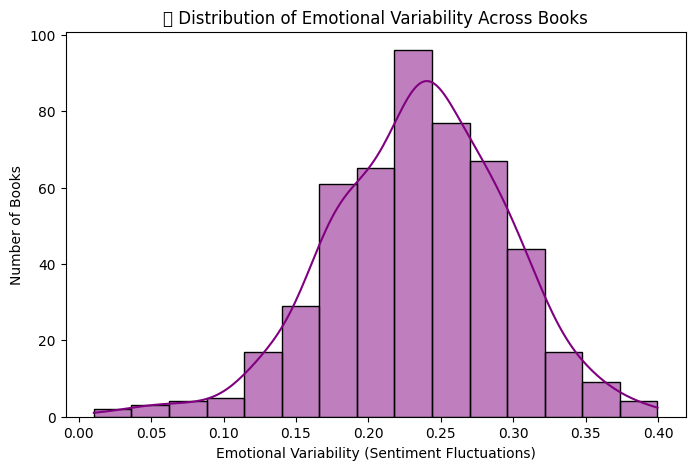

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Arc_Volatility"].dropna(), bins=15, kde=True, color='purple')
plt.xlabel("Emotional Variability (Sentiment Fluctuations)")
plt.ylabel("Number of Books")
plt.title("📊 Distribution of Emotional Variability Across Books")
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


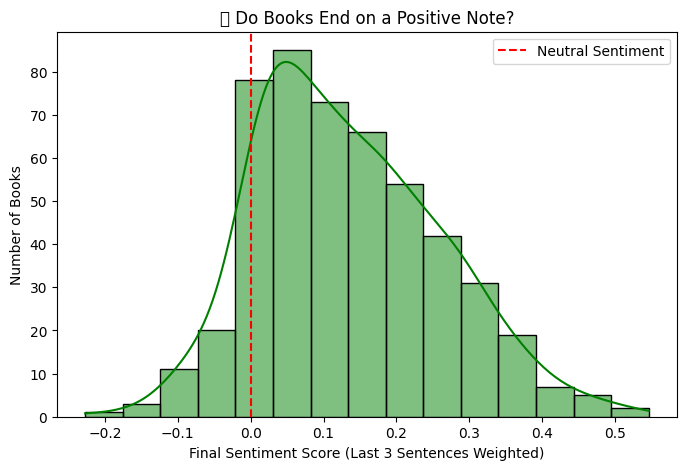

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Weighted_Final_Sentiment"].dropna(), bins=15, kde=True, color='green')
plt.axvline(0, color='red', linestyle='--', label="Neutral Sentiment")
plt.xlabel("Final Sentiment Score (Last 3 Sentences Weighted)")
plt.ylabel("Number of Books")
plt.title("📈 Do Books End on a Positive Note?")
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128214 (\N{OPEN BOOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


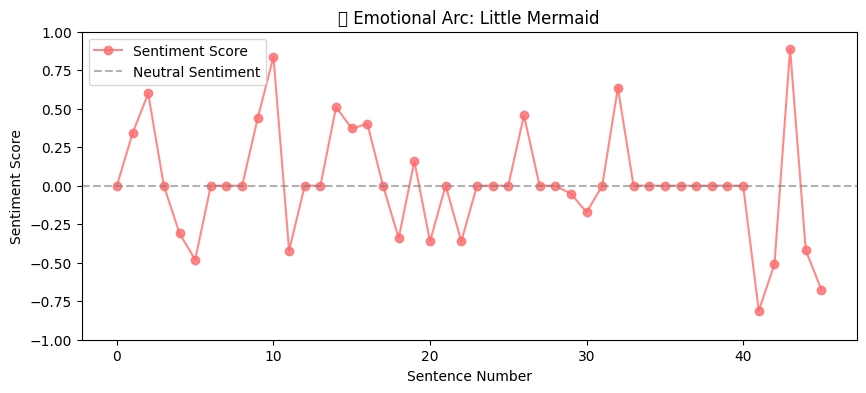

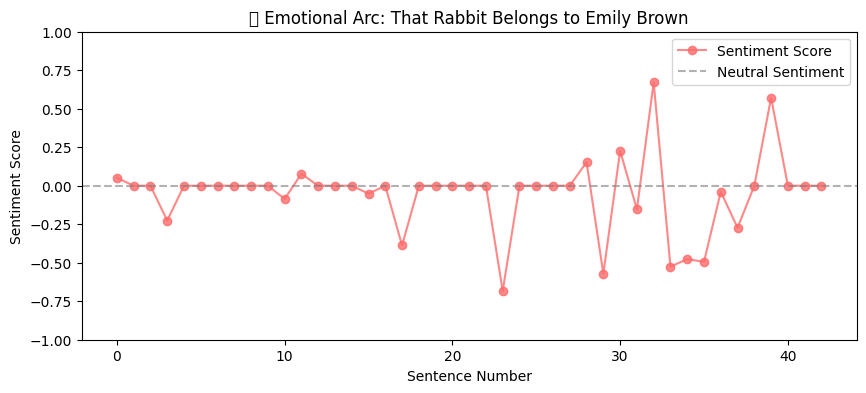

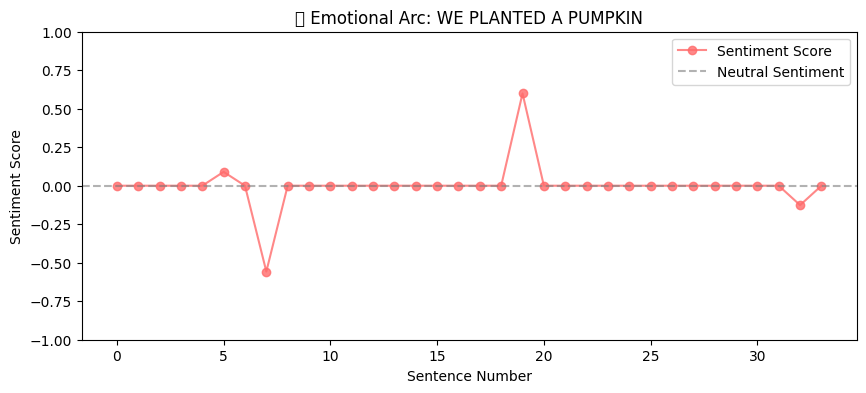

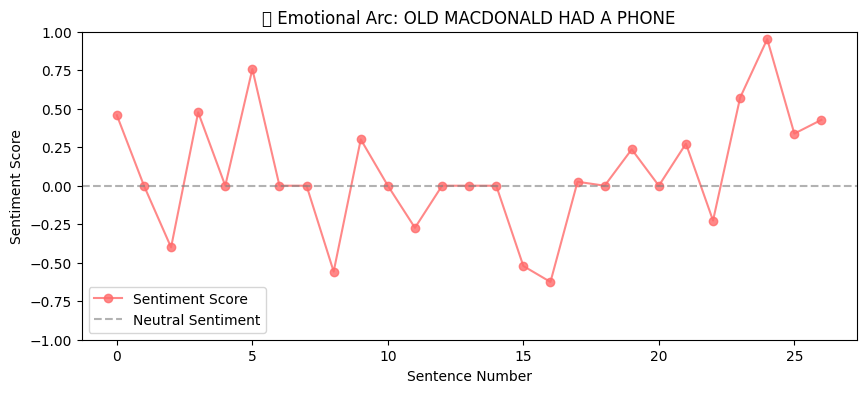

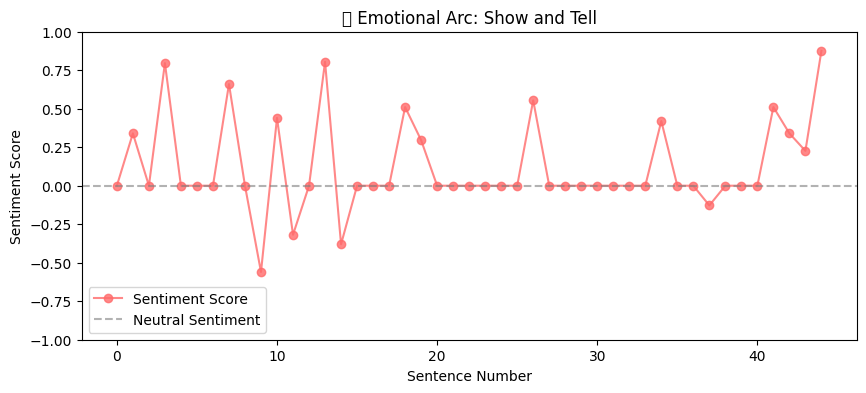

In [26]:
def plot_emotional_arc(text, title="Contextual Emotional Arc"):
    """Plots the emotional arc by computing sentiment for each sentence."""
    sentences = sent_tokenize(text)
    if len(sentences) < 2:
        print(f"⚠️ Not enough sentences in '{title}' for analysis.")
        return

    sia = SentimentIntensityAnalyzer()
    sentiments = [sia.polarity_scores(sent)['compound'] for sent in sentences]

    plt.figure(figsize=(10, 4))
    plt.plot(sentiments, marker='o', linestyle='-', color='#FF6B6B', alpha=0.8, label="Sentiment Score")
    plt.axhline(0, color='gray', linestyle='--', alpha=0.6, label="Neutral Sentiment")
    plt.title(f"📖 Emotional Arc: {title}")
    plt.ylabel("Sentiment Score")
    plt.xlabel("Sentence Number")
    plt.ylim(-1, 1)
    plt.legend()
    plt.show()

# Generate emotional arc plots for some books
plot_emotional_arc(df[df["Book Title"] == "Little Mermaid"]["Content"].iloc[0], "Little Mermaid")
plot_emotional_arc(df[df["Book Title"] == "That Rabbit Belongs to Emily Brown"]["Content"].iloc[0], "That Rabbit Belongs to Emily Brown")
plot_emotional_arc(df[df["Book Title"] == "WE PLANTED A PUMPKIN"]["Content"].iloc[0], "WE PLANTED A PUMPKIN")
plot_emotional_arc(df[df["Book Title"] == "OLD MACDONALD HAD A PHONE"]["Content"].iloc[0], "OLD MACDONALD HAD A PHONE")
plot_emotional_arc(df[df["Book Title"] == "Show and Tell"]["Content"].iloc[0], "Show and Tell")

# **Thematic Analysis**

In [27]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Clean text for LDA
df["Cleaned_Content_Thematic"] = df["Content"].apply(clean_for_thematic_analysis)

# Create document-term matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2))
doc_term_matrix = vectorizer.fit_transform(df["Cleaned_Content_Thematic"])

# Train LDA model
n_topics = 5  # Adjust based on your dataset
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(doc_term_matrix)

# Extract topic-word distributions
feature_names = vectorizer.get_feature_names_out()

In [28]:
# Get dominant topic for each book
topic_distributions = lda.transform(doc_term_matrix)
df["Dominant_Topic"] = topic_distributions.argmax(axis=1) + 1  # +1 for 1-based indexing

# Map topic numbers to theme labels (customize based on your output)
topic_labels = {
    1: "Adventure & Sacrifice",
    2: "Growth & Seasons",
    3: "Ownership & Persistence",
    4: "Technology & Balance",
    5: "Imagination & Learning"
}
df["Theme"] = df["Dominant_Topic"].map(topic_labels)

In [29]:
def print_top_words(model, feature_names, n_top_words=10):
    """Prints top words per topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words = " | ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(f"Topic {topic_idx + 1}: {top_words}")

print_top_words(lda, feature_names)

Topic 1: say | honey | dad | go | lola | look | one | like | get | come
Topic 2: say | go | one | look | big | get | come | like | baby | little
Topic 3: like | say | little | bear | go | one | time | big | look | book
Topic 4: say | sit | go | like | daisy | one | look | make | see | time
Topic 5: say | would | go | one | make | day | love | get | could | look


# **Analyze Books (Rule-Based)**

In [69]:
def analyze_book(row):
    """Generates an interactive reading suitability report with structured categories and engaging cues."""
    insights = {
        'suitability_tier': '',
        'engagement': [],
        'readability': [],
        'lexical_diversity': [],
        'sentiment_analysis': [],
        'actionable_tips': []
    }

    tier = 0  # Reset tier counter

    # ======================== 🎤 ENGAGEMENT FEATURES (AFFECTS SUITABILITY) ========================
    if row["Phrase_Repetition"] >= 0.15:
        insights['engagement'].append("🔁 This book loves to repeat! Kids will catch on and join in easily.")
        tier += 1
    else:
        insights['engagement'].append("😕 Not much repetition—try adding your own fun catchphrase while reading!")

    if row["Rhyme_Score"] >= 0.15:
        insights['engagement'].append("🎶 Rhyme time! The rhythm makes it fun to read aloud.")
        tier += 1
    else:
        insights['engagement'].append("🗣 No rhyming here—try reading with extra expression to keep it lively!")

    if row["Question_Score"] >= 0.15:
        insights['engagement'].append("❓ Lots of questions! This book will get kids thinking and talking.")
        tier += 1
    else:
        insights['engagement'].append("🤔 Few built-in questions—pause and ask 'What do you think happens next?'")

    # If no engagement features were triggered, add a default statement
    if not insights['engagement']:
        insights['engagement'].append("📘 This book focuses more on storytelling rather than patterns or repetition.")

    # ======================== 📖 READABILITY & COMPLEXITY ========================
    if row["Flesch_Reading_Ease"] >= 85:
        insights['readability'].append("📝 Very easy to read—great for young listeners and beginner readers.")
    elif 70 <= row["Flesch_Reading_Ease"] < 85:
        insights['readability'].append("📚 Slightly more complex—might need a little explaining.")

    if row["Sentence_Length"] <= 8:
        insights['readability'].append("🔡 Short, simple sentences—ideal for early readers.")
    else:
        insights['readability'].append("✍️ Some longer sentences—try pausing or using different tones for clarity.")

    if row["Clause_Density"] < 0.5:
        insights['readability'].append("✅ Simple sentence structure—great for young readers.")
    else:
        insights['readability'].append("⚠️ More clauses per sentence—may require extra explanation.")

    # If no readability insights were triggered, add a default statement
    if not insights['readability']:
        insights['readability'].append("📖 A balanced mix of simple and complex sentences.")


    # ======================== 📖 LEXICAL DIVERSITY (VOCABULARY & COMPLEXITY) ========================
    if 0.65 <= row["MATTR"] <= 0.80:
        insights['lexical_diversity'].append("📖 Balanced vocabulary—rich but still understandable for kids.")
        tier += 1
    elif row["MATTR"] > 0.80:
        insights['lexical_diversity'].append("🧐 Lots of new words! A great chance to introduce fun vocabulary.")

    if row["MTLD"] <= 60:
        insights['lexical_diversity'].append("📜 The story flows smoothly and is easy to follow.")
    else:
        insights['lexical_diversity'].append("🔍 More complex storytelling—ideal for kids who love rich narratives.")

    if row["HDD"] <= 0.75:
        insights['lexical_diversity'].append("✅ Uses familiar words—great for young readers.")
    else:
        insights['lexical_diversity'].append("⚠️ High vocabulary diversity—some words may need explanation.")

    # If no lexical diversity insights were triggered, add a default statement
    if not insights['lexical_diversity']:
        insights['lexical_diversity'].append("🔤 The vocabulary is simple and easy to understand.")


    # ======================== 💖 EMOTIONAL & SENTIMENT JOURNEY ========================
    if row["Arc_Range"] >= 1.0:
        insights['sentiment_analysis'].append("🎢 Emotional rollercoaster! Highs and lows will keep kids engaged.")
    elif row["Arc_Range"] < 0.5:
        insights['sentiment_analysis'].append("🛤 A steady emotional tone—perfect for winding down before bed.")

    if row["Arc_Resolution"] > 0:
        insights['sentiment_analysis'].append("🎉 A happy ending! Kids will finish on a feel-good note.")
    elif row["Arc_Resolution"] < 0:
        insights['sentiment_analysis'].append("💔 Ends on a bittersweet note—prepare for questions and discussion.")

    if row["Arc_Volatility"] > 0.25:
        insights['sentiment_analysis'].append("🎭 Plenty of emotional ups and downs—great for expressive reading!")
    elif row["Arc_Volatility"] < 0.15:
        insights['sentiment_analysis'].append("🌊 A calm and steady emotional journey.")

    if row["Sentiment_Transitions"] >= 15:
        insights['sentiment_analysis'].append("🎭 Many emotional twists—this story will keep kids engaged!")
        tier += 1
    else:
        insights['sentiment_analysis'].append("📖 A steady emotional journey—great for a calm read.")

    if row["Weighted_Final_Sentiment"] > 0.2:
        insights['engagement'].append("😊 Ends on a happy note—perfect for bedtime or a cheerful read!")
    elif row["Weighted_Final_Sentiment"] < -0.2:
        insights['engagement'].append("😢 A bit of a sad ending—be ready for some extra cuddles and conversation.")

    # If no sentiment insights were triggered, add a default statement
    if not insights['sentiment_analysis']:
        insights['sentiment_analysis'].append("🛤 A neutral emotional journey with minimal shifts.")


    # ======================== ⭐ SUITABILITY TIER ASSIGNMENT (BASED ONLY ON ENGAGEMENT) ========================

    tier_map = {
        0: ('❌ Not Recommended', 0, ["This book lacks key interactive elements."]),
        1: ('⭐ Limited Suitability', 1, ["Best for passive listening, but not ideal for engagement."]),
        2: ('⭐⭐ Moderate', 2, ["Can be interactive with effort—add sound effects or roleplay!"]),
        3: ('⭐⭐⭐ Strong', 3, ["Good for guided interaction—kids will stay engaged."]),
        4: ('⭐⭐⭐⭐ Ideal', 4, ["Perfect for interactive reading—predictable, engaging, and full of fun elements!"])
    }
    insights['suitability_tier'], suitability_numeric, _ = tier_map.get(tier, ('⚖️ Unrated', np.nan, []))

    # ======================== 🔹 ACTIONABLE TIPS ========================
    tips = []
    if row["Phrase_Repetition"] >= 0.15:
        tips.append("🔁 Let kids guess the next repeated phrase—build anticipation!")
    if row["Rhyme_Score"] >= 0.15:
        tips.append("🎤 Clap along or emphasize rhymes to make it fun.")
    if row["Question_Score"] >= 0.15:
        tips.append("🤔 Pause after each question and let kids think aloud.")
    if row["Sentiment_Transitions"] >= 15:
        tips.append("🎭 Act out emotional moments—use voices, expressions, or props!")
    if row["Weighted_Final_Sentiment"] < -0.2:
        tips.append("💬 Talk about the ending—ask kids how it made them feel.")
    if row["Clause_Density"] >= 0.5:
        tips.append("🧐 Break longer sentences into smaller parts while reading aloud.")
    if row["HDD"] > 0.75:
        tips.append("📖 Pause to explain tricky words using pictures or gestures.")

    insights['actionable_tips'] = tips if tips else ["No specific tips needed."]

    # ======================== 📊 FORMATTING OUTPUT ========================
    return pd.Series([
        insights['suitability_tier'],
        suitability_numeric,
        "\n".join(insights['engagement']),
        "\n".join(insights['readability']),
        "\n".join(insights['lexical_diversity']),
        "\n".join(insights['sentiment_analysis']),
        "\n".join(insights['actionable_tips'])
    ])

# Apply to DataFrame
df[["Suitability", "Suitability_Numeric", "Engagement Features", "Readability & Complexity",
    "Lexical Diversity", "Emotional & Sentiment Journey", "Actionable Tips"]] = df.apply(analyze_book, axis=1)

df[["Book Title", "Suitability", "Suitability_Numeric", "Engagement Features", "Readability & Complexity",
    "Lexical Diversity", "Emotional & Sentiment Journey", "Actionable Tips"]].head()

,Book Title,Suitability,Suitability_Numeric,Engagement Features,Readability & Complexity,Lexical Diversity,Emotional & Sentiment Journey,Actionable Tips
0,Little Mermaid,⭐⭐ Moderate,2.0,😕 Not much repetition—try adding your own fun ...,📝 Very easy to read—great for young listeners ...,🧐 Lots of new words! A great chance to introdu...,🎢 Emotional rollercoaster! Highs and lows will...,🤔 Pause after each question and let kids think...
1,That Rabbit Belongs to Emily Brown,⭐⭐⭐ Strong,3.0,🔁 This book loves to repeat! Kids will catch o...,📚 Slightly more complex—might need a little ex...,🧐 Lots of new words! A great chance to introdu...,🎢 Emotional rollercoaster! Highs and lows will...,🔁 Let kids guess the next repeated phrase—buil...
2,WE PLANTED A PUMPKIN,⭐⭐⭐⭐ Ideal,4.0,🔁 This book loves to repeat! Kids will catch o...,📝 Very easy to read—great for young listeners ...,📖 Balanced vocabulary—rich but still understan...,🛤 A neutral emotional journey with minimal shi...,🔁 Let kids guess the next repeated phrase—buil...
3,OLD MACDONALD HAD A PHONE,⭐⭐⭐ Strong,3.0,😕 Not much repetition—try adding your own fun ...,📝 Very easy to read—great for young listeners ...,🧐 Lots of new words! A great chance to introdu...,🎢 Emotional rollercoaster! Highs and lows will...,🎤 Clap along or emphasize rhymes to make it fu...
4,Show and Tell,⭐⭐ Moderate,2.0,😕 Not much repetition—try adding your own fun ...,📚 Slightly more complex—might need a little ex...,🧐 Lots of new words! A great chance to introdu...,🎢 Emotional rollercoaster! Highs and lows will...,🤔 Pause after each question and let kids think...


In [56]:
# Save to CSV (best for structured data)
df.to_csv("analyzed_books.csv", index=False)

print("✅ Analyzed data saved successfully!")


✅ Analyzed data saved successfully!


In [31]:
# Install required libraries
!pip install pandas numpy scikit-learn sentence-transformers matplotlib

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt


In [71]:
# Save to CSV (including the Suitability_Numeric column)
df.to_csv("analyzed_books.csv", index=False)

print("✅ Analyzed data saved successfully, including Suitability_Numeric!")


✅ Analyzed data saved successfully, including Suitability_Numeric!


# **Analyze Books (Machine Learning)**

In [86]:
# Load your dataset
df = pd.read_csv("/content/analyzed_books.csv")

# Define features and labels (adjust columns as needed)
features = ['Phrase_Repetition', 'Rhyme_Score', 'Question_Score', 'Flesch_Reading_Ease',
            'Sentence_Length', 'Clause_Density', 'MATTR', 'MTLD', 'HDD', 'Sentiment_Transitions']
X = df[features]
y = df["Suitability_Numeric"]  # Your 0-4 labels

In [93]:
print(df["Suitability_Numeric"].isnull().sum())  # Check how many NaN values exist

0


In [88]:
df = df[df["Suitability"] != "⚖️ Unrated"]  # Remove "Unrated" books
df = df.dropna(subset=["Suitability_Numeric"])  # Remove NaNs in Suitability_Numeric

In [89]:
print(df["Suitability"].value_counts())  # Check remaining categories
print(df["Suitability_Numeric"].isnull().sum())  # Ensure no NaNs remain

Suitability
⭐⭐⭐ Strong               151
⭐⭐ Moderate              132
⭐⭐⭐⭐ Ideal                98
⭐ Limited Suitability     61
❌ Not Recommended         14
Name: count, dtype: int64
0


Cross-Validation Accuracy: 0.86


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


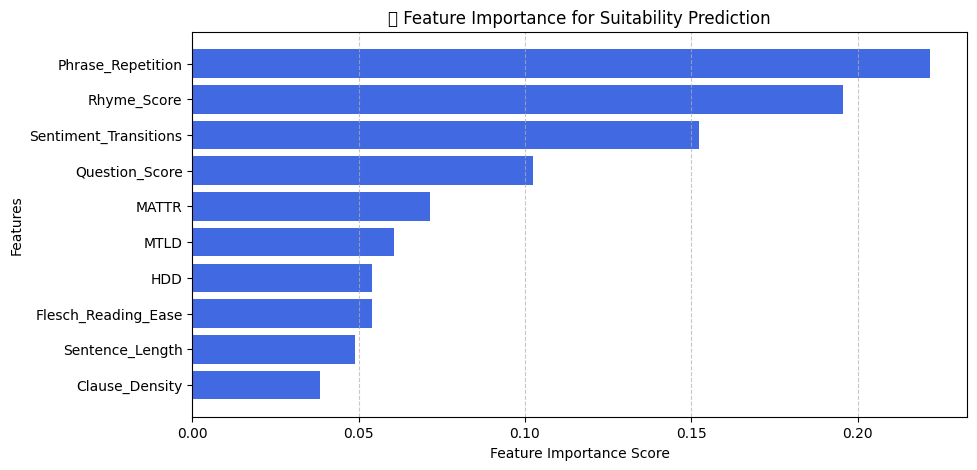

In [91]:
# Define features and labels
X = df[features]
y = df["Suitability_Numeric"]

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Evaluate with cross-validation
scores = cross_val_score(model, X, y, cv=5)  # 5-fold cross-validation
print(f"Cross-Validation Accuracy: {np.mean(scores):.2f}")

# Get feature importance
importances = model.feature_importances_
feature_names = np.array(features)

# Sort feature importance in descending order
sorted_idx = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_idx]
sorted_features = feature_names[sorted_idx]

# Plot Feature Importance
plt.figure(figsize=(10, 5))
plt.barh(sorted_features, sorted_importances, color="royalblue")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("📊 Feature Importance for Suitability Prediction")
plt.gca().invert_yaxis()  # Highest importance on top
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [92]:
from sklearn.metrics import accuracy_score
import numpy as np

# Select 5 most relevant features
top_features = ["Phrase_Repetition", "Rhyme_Score", "Sentiment_Transitions", "Question_Score", "MATTR"]

# Generate possible threshold values
thresholds = {feature: np.linspace(df[feature].min(), df[feature].max(), 20) for feature in top_features}

best_thresholds = {}
best_accuracy = 0

# Try different threshold combinations
for pr in thresholds["Phrase_Repetition"]:
    for rs in thresholds["Rhyme_Score"]:
        for st in thresholds["Sentiment_Transitions"]:
            for qs in thresholds["Question_Score"]:
                for mattr in thresholds["MATTR"]:
                    # Generate predicted suitability score based on thresholds
                    y_pred = (
                        (df["Phrase_Repetition"] >= pr).astype(int) +
                        (df["Rhyme_Score"] >= rs).astype(int) +
                        (df["Sentiment_Transitions"] >= st).astype(int) +
                        (df["Question_Score"] >= qs).astype(int) +
                        (df["MATTR"] >= mattr).astype(int)
                    )

                    # Compare predicted suitability with actual suitability tiers
                    acc = accuracy_score(df["Suitability_Numeric"], y_pred)
                    if acc > best_accuracy:
                        best_accuracy = acc
                        best_thresholds = {
                            "Phrase_Repetition": pr,
                            "Rhyme_Score": rs,
                            "Sentiment_Transitions": st,
                            "Question_Score": qs,
                            "MATTR": mattr
                        }

print(f"🔹 Best Thresholds: {best_thresholds} (Accuracy: {best_accuracy:.2f})")

🔹 Best Thresholds: {'Phrase_Repetition': 0.12838170191834725, 'Rhyme_Score': 0.15484295556862715, 'Sentiment_Transitions': 13.421052631578949, 'Question_Score': 0.10526315789473684, 'MATTR': 0.9222222222222224} (Accuracy: 0.77)


In [94]:
# Get feature importance from Random Forest Model
feature_importance = model.feature_importances_

# Create a DataFrame for better visibility
feature_importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importance})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Display feature importance
print(feature_importance_df)


                 Feature  Importance
0      Phrase_Repetition    0.221900
1            Rhyme_Score    0.195512
9  Sentiment_Transitions    0.152336
2         Question_Score    0.102577
6                  MATTR    0.071541
7                   MTLD    0.060729
8                    HDD    0.053988
3    Flesch_Reading_Ease    0.053892
4        Sentence_Length    0.048990
5         Clause_Density    0.038535


In [96]:
# Normalize importance scores (convert to weight scale from 1.0 to 1.5)
feature_importance_df["Weight"] = 1.0 + (feature_importance_df["Importance"] / feature_importance_df["Importance"].max()) * 0.5

# Convert into a dictionary for thresholding
weights = feature_importance_df.set_index("Feature")["Weight"].to_dict()

print("Assigned Weights:", weights)


Assigned Weights: {'Phrase_Repetition': 1.5, 'Rhyme_Score': 1.4405400068613654, 'Sentiment_Transitions': 1.3432530108566396, 'Question_Score': 1.2311331734859745, 'MATTR': 1.161200551437895, 'MTLD': 1.136837418368065, 'HDD': 1.121649610595118, 'Flesch_Reading_Ease': 1.1214325376898309, 'Sentence_Length': 1.1103880797928707, 'Clause_Density': 1.0868284222681224}


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
from itertools import product  # For iterating over multiple threshold combinations

# Select 5 most relevant features based on previous analysis
top_features = ["Phrase_Repetition", "Rhyme_Score", "Sentiment_Transitions", "Question_Score", "MATTR"]

# Generate finer-grained threshold values
num_thresholds = 50  # Increase the number of search points for better accuracy
thresholds = {feature: np.linspace(df[feature].min(), df[feature].max(), num_thresholds) for feature in top_features}

best_thresholds = {}
best_accuracy = 0


# Apply weights dynamically
for pr, rs, st, qs, mattr in product(thresholds["Phrase_Repetition"], thresholds["Rhyme_Score"],
                                      thresholds["Sentiment_Transitions"], thresholds["Question_Score"],
                                      thresholds["MATTR"]):

    # Compute weighted suitability score based on learned weights
    y_pred = (
        (df["Phrase_Repetition"] >= pr).astype(int) * weights["Phrase_Repetition"] +
        (df["Rhyme_Score"] >= rs).astype(int) * weights["Rhyme_Score"] +
        (df["Sentiment_Transitions"] >= st).astype(int) * weights["Sentiment_Transitions"] +
        (df["Question_Score"] >= qs).astype(int) * weights["Question_Score"] +
        (df["MATTR"] >= mattr).astype(int) * weights["MATTR"]
    )

    # Normalize predictions to fit 0-4 scale
    y_pred = np.round(y_pred / np.max(y_pred) * 4)

    # Calculate accuracy
    acc = accuracy_score(df["Suitability_Numeric"], y_pred)

    # Store best thresholds if accuracy improves
    if acc > best_accuracy:
        best_accuracy = acc
        best_thresholds = {
            "Phrase_Repetition": pr,
            "Rhyme_Score": rs,
            "Sentiment_Transitions": st,
            "Question_Score": qs,
            "MATTR": mattr
        }

print(f"🔹 Optimized Thresholds: {best_thresholds} (Accuracy: {best_accuracy:.2f})")


In [ ]:
def analyze_book(row):
    """Generates an interactive reading suitability report with structured categories and engaging cues."""
    insights = {
        'suitability_tier': '',
        'engagement': [],
        'readability': [],
        'lexical_diversity': [],
        'sentiment_analysis': [],
        'actionable_tips': []
    }

    tier = 0  # Reset tier counter

    # ======================== 🎤 ENGAGEMENT FEATURES (AFFECTS SUITABILITY) ========================
    if row["Phrase_Repetition"] >= 0.128:
        insights['engagement'].append("🔁 This book loves to repeat! Kids will catch on and join in easily.")
        tier += 1
    else:
        insights['engagement'].append("😕 Not much repetition—try adding your own fun catchphrase while reading!")

    if row["Rhyme_Score"] >= 0.154:
        insights['engagement'].append("🎶 Rhyme time! The rhythm makes it fun to read aloud.")
        tier += 1
    else:
        insights['engagement'].append("🗣 No rhyming here—try reading with extra expression to keep it lively!")

    if row["Question_Score"] >= 0.105:
        insights['engagement'].append("❓ Lots of questions! This book will get kids thinking and talking.")
        tier += 1
    else:
        insights['engagement'].append("🤔 Few built-in questions—pause and ask 'What do you think happens next?'")

    # If no engagement features were triggered, add a default statement
    if not insights['engagement']:
        insights['engagement'].append("📘 This book focuses more on storytelling rather than patterns or repetition.")

    # ======================== 📖 READABILITY & COMPLEXITY ========================
    if row["Flesch_Reading_Ease"] >= 85:
        insights['readability'].append("📝 Very easy to read—great for young listeners and beginner readers.")
    elif 70 <= row["Flesch_Reading_Ease"] < 85:
        insights['readability'].append("📚 Slightly more complex—might need a little explaining.")

    if row["Sentence_Length"] <= 8:
        insights['readability'].append("🔡 Short, simple sentences—ideal for early readers.")
    else:
        insights['readability'].append("✍️ Some longer sentences—try pausing or using different tones for clarity.")

    if row["Clause_Density"] < 0.5:
        insights['readability'].append("✅ Simple sentence structure—great for young readers.")
    else:
        insights['readability'].append("⚠️ More clauses per sentence—may require extra explanation.")

    # If no readability insights were triggered, add a default statement
    if not insights['readability']:
        insights['readability'].append("📖 A balanced mix of simple and complex sentences.")


    # ======================== 📖 LEXICAL DIVERSITY (VOCABULARY & COMPLEXITY) ========================
    if 0.65 <= row["MATTR"] <= 0.922:
        insights['lexical_diversity'].append("📖 Balanced vocabulary—rich but still understandable for kids.")
        tier += 1
    elif row["MATTR"] > 0.80:
        insights['lexical_diversity'].append("🧐 Lots of new words! A great chance to introduce fun vocabulary.")

    if row["MTLD"] <= 60:
        insights['lexical_diversity'].append("📜 The story flows smoothly and is easy to follow.")
    else:
        insights['lexical_diversity'].append("🔍 More complex storytelling—ideal for kids who love rich narratives.")

    if row["HDD"] <= 0.75:
        insights['lexical_diversity'].append("✅ Uses familiar words—great for young readers.")
    else:
        insights['lexical_diversity'].append("⚠️ High vocabulary diversity—some words may need explanation.")

    # If no lexical diversity insights were triggered, add a default statement
    if not insights['lexical_diversity']:
        insights['lexical_diversity'].append("🔤 The vocabulary is simple and easy to understand.")


    # ======================== 💖 EMOTIONAL & SENTIMENT JOURNEY ========================
    if row["Arc_Range"] >= 1.0:
        insights['sentiment_analysis'].append("🎢 Emotional rollercoaster! Highs and lows will keep kids engaged.")
    elif row["Arc_Range"] < 0.5:
        insights['sentiment_analysis'].append("🛤 A steady emotional tone—perfect for winding down before bed.")

    if row["Arc_Resolution"] > 0:
        insights['sentiment_analysis'].append("🎉 A happy ending! Kids will finish on a feel-good note.")
    elif row["Arc_Resolution"] < 0:
        insights['sentiment_analysis'].append("💔 Ends on a bittersweet note—prepare for questions and discussion.")

    if row["Arc_Volatility"] > 0.25:
        insights['sentiment_analysis'].append("🎭 Plenty of emotional ups and downs—great for expressive reading!")
    elif row["Arc_Volatility"] < 0.15:
        insights['sentiment_analysis'].append("🌊 A calm and steady emotional journey.")

    if row["Sentiment_Transitions"] >= 13.42:
        insights['sentiment_analysis'].append("🎭 Many emotional twists—this story will keep kids engaged!")
        tier += 1
    else:
        insights['sentiment_analysis'].append("📖 A steady emotional journey—great for a calm read.")

    if row["Weighted_Final_Sentiment"] > 0.2:
        insights['engagement'].append("😊 Ends on a happy note—perfect for bedtime or a cheerful read!")
    elif row["Weighted_Final_Sentiment"] < -0.2:
        insights['engagement'].append("😢 A bit of a sad ending—be ready for some extra cuddles and conversation.")

    # If no sentiment insights were triggered, add a default statement
    if not insights['sentiment_analysis']:
        insights['sentiment_analysis'].append("🛤 A neutral emotional journey with minimal shifts.")


    # ======================== ⭐ SUITABILITY TIER ASSIGNMENT (BASED ONLY ON ENGAGEMENT) ========================

    tier_map = {
        0: ('❌ Not Recommended', 0, ["This book lacks key interactive elements."]),
        1: ('⭐ Limited Suitability', 1, ["Best for passive listening, but not ideal for engagement."]),
        2: ('⭐⭐ Moderate', 2, ["Can be interactive with effort—add sound effects or roleplay!"]),
        3: ('⭐⭐⭐ Strong', 3, ["Good for guided interaction—kids will stay engaged."]),
        4: ('⭐⭐⭐⭐ Ideal', 4, ["Perfect for interactive reading—predictable, engaging, and full of fun elements!"])
    }
    insights['suitability_tier'], suitability_numeric, _ = tier_map.get(tier, ('⚖️ Unrated', np.nan, []))

    # ======================== 🔹 ACTIONABLE TIPS ========================
    tips = []
    tips = []
    if row["Phrase_Repetition"] >= 0.128:
        tips.append("🔁 Let kids guess the next repeated phrase—build anticipation!")
    if row["Rhyme_Score"] >= 0.154:
        tips.append("🎤 Clap along or emphasize rhymes to make it fun.")
    if row["Question_Score"] >= 0.105:
        tips.append("🤔 Pause after each question and let kids think aloud.")
    if row["Sentiment_Transitions"] >= 13.42:
        tips.append("🎭 Act out emotional moments—use voices, expressions, or props!")
    if row["MATTR"] >= 0.922:
        tips.append("📖 Introduce new words by using fun gestures or pictures.")
    if row["Weighted_Final_Sentiment"] < -0.2:
        tips.append("💬 Talk about the ending—ask kids how it made them feel.")
    if row["Clause_Density"] >= 0.5:
        tips.append("🧐 Break longer sentences into smaller parts while reading aloud.")
    if row["HDD"] > 0.75:
        tips.append("📖 Pause to explain tricky words using pictures or gestures.")

    insights['actionable_tips'] = tips if tips else ["No specific tips needed."]

    # ======================== 📊 FORMATTING OUTPUT ========================
    return pd.Series([
        insights['suitability_tier'],
        suitability_numeric,
        "\n".join(insights['engagement']),
        "\n".join(insights['readability']),
        "\n".join(insights['lexical_diversity']),
        "\n".join(insights['sentiment_analysis']),
        "\n".join(insights['actionable_tips'])
    ])

# Apply to DataFrame
df[["Suitability", "Suitability_Numeric", "Engagement Features", "Readability & Complexity",
    "Lexical Diversity", "Emotional & Sentiment Journey", "Actionable Tips"]] = df.apply(analyze_book, axis=1)

df[["Book Title", "Suitability", "Suitability_Numeric", "Engagement Features", "Readability & Complexity",
    "Lexical Diversity", "Emotional & Sentiment Journey", "Actionable Tips"]].head()